In [ ]:
"""
import shutil
shutil.rmtree("CRP_dataset")
"""

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
shutil.copytree(
    '/content/drive/MyDrive/CRP_dataset',
    'CRP_dataset'
)

'CRP_dataset'

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import numpy as np
import random
import os
from dataload import CustomImageDataset
from models import BwCombinedInteractModel50
from sklearn.model_selection import StratifiedShuffleSplit

num_classes = 4
batch_size = 32
max_epochs = 100
patience = 20
repeats = 3

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_curves(train_losses, train_accs, val_accs, seed):
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, train_losses, 'b-', label='Train Loss')
    ax1.set_title(f'Training Loss (Seed {seed})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_accs, 'b-', label='Train Acc')
    ax2.plot(epochs, val_accs,   'r-', label='Val Acc')
    ax2.set_title(f'Accuracy (Seed {seed})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'curves_seed_{seed}.png', dpi=150)
    plt.show()

def plot_confusion_matrix(all_labels, all_preds, seed, class_names=['190', '2800', '3300', '560']):
    cm = confusion_matrix(all_labels, all_preds)
    # Normalize to percentage
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'Confusion Matrix - Counts (Seed {seed})')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    # Percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'Confusion Matrix - % (Seed {seed})')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_seed_{seed}.png', dpi=150)
    plt.show()

Starting load Dataset: CRP_dataset/crp_iphone/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_iphone/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_iphone/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Seed 42 Epoch 1: Loss=0.7254 | Train Acc=0.7071 | Val Acc=0.3000
Seed 42 Epoch 2: Loss=0.0708 | Train Acc=0.9874 | Val Acc=0.2750
Seed 42 Epoch 3: Loss=0.0212 | Train Acc=1.0000 | Val Acc=0.4750
Seed 42 Epoch 4: Loss=0.0152 | Train Acc=1.0000 | Val Acc=0.6375
Seed 42 Epoch 5: Loss=0.0067 | Train Acc=1.0000 | Val Acc=0.7250
Seed 42 Epoch 6: Loss=0.0044 | Train Acc=1.0000 | Val Acc=0.7750
Seed 42 Epoch 7: Loss=0.0048 | Train Acc=1.0000 | Val Acc=0.9000
Seed 42 Epoch 8: Loss=0.0054 | Train Acc=1.00

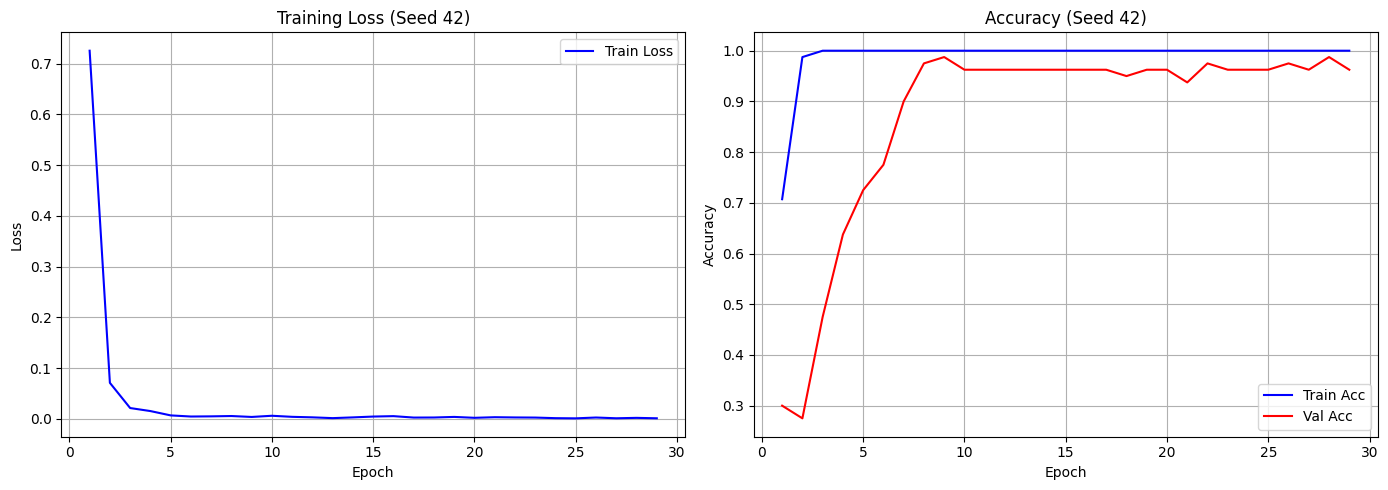

Loading best model from best_model_seed_42.pt for testing
Seed 42: Test Acc = 0.9625



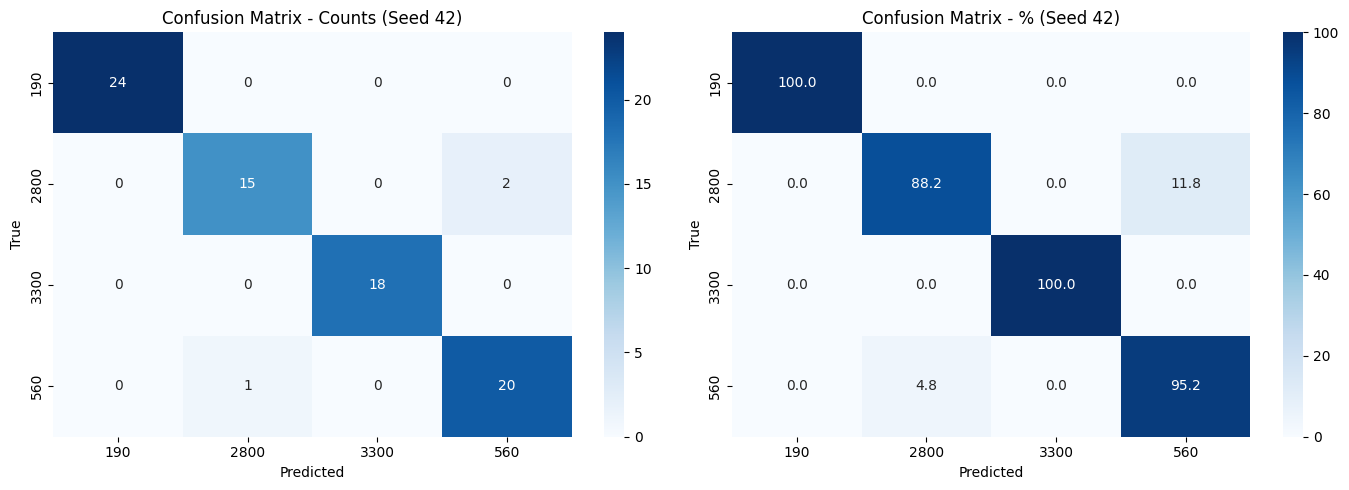

Seed 142 Epoch 1: Loss=0.7846 | Train Acc=0.7071 | Val Acc=0.3375
Seed 142 Epoch 2: Loss=0.1003 | Train Acc=0.9874 | Val Acc=0.3625
Seed 142 Epoch 3: Loss=0.0265 | Train Acc=0.9958 | Val Acc=0.3625
Seed 142 Epoch 4: Loss=0.0178 | Train Acc=1.0000 | Val Acc=0.5125
Seed 142 Epoch 5: Loss=0.0076 | Train Acc=1.0000 | Val Acc=0.6750
Seed 142 Epoch 6: Loss=0.0037 | Train Acc=1.0000 | Val Acc=0.8500
Seed 142 Epoch 7: Loss=0.0051 | Train Acc=1.0000 | Val Acc=0.9750
Seed 142 Epoch 8: Loss=0.0032 | Train Acc=1.0000 | Val Acc=0.9750
Seed 142 Epoch 9: Loss=0.0031 | Train Acc=1.0000 | Val Acc=1.0000
Seed 142 Epoch 10: Loss=0.0032 | Train Acc=1.0000 | Val Acc=1.0000
Seed 142 Epoch 11: Loss=0.0187 | Train Acc=0.9958 | Val Acc=1.0000
Seed 142 Epoch 12: Loss=0.0024 | Train Acc=1.0000 | Val Acc=0.9875
Seed 142 Epoch 13: Loss=0.0048 | Train Acc=1.0000 | Val Acc=0.9750
Seed 142 Epoch 14: Loss=0.0040 | Train Acc=1.0000 | Val Acc=0.9875
Seed 142 Epoch 15: Loss=0.0055 | Train Acc=1.0000 | Val Acc=0.9750
Seed

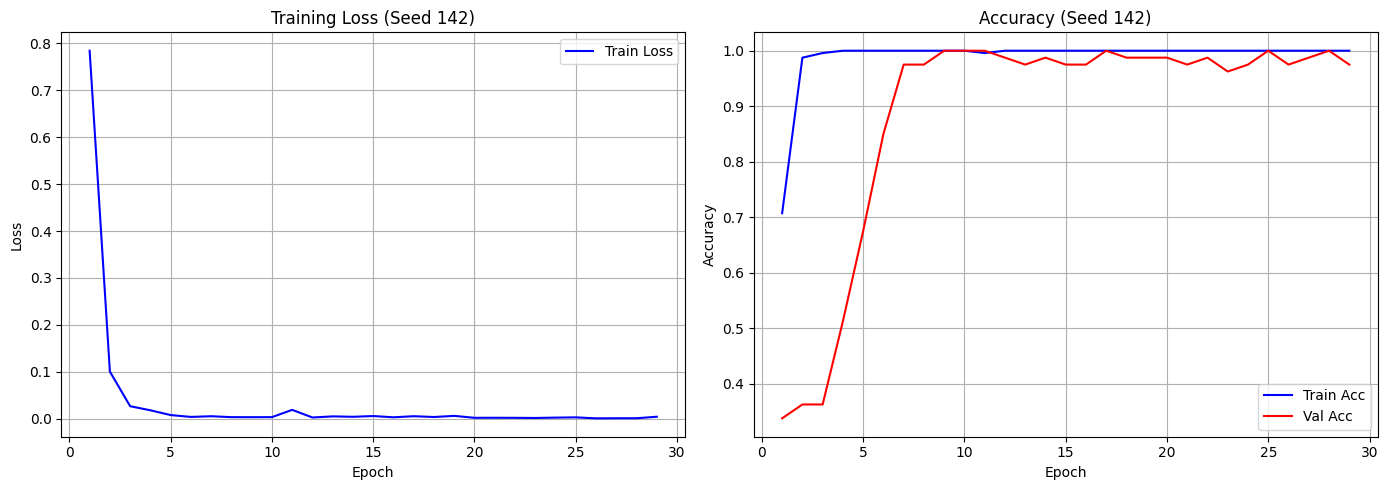

Loading best model from best_model_seed_142.pt for testing
Seed 142: Test Acc = 0.9750



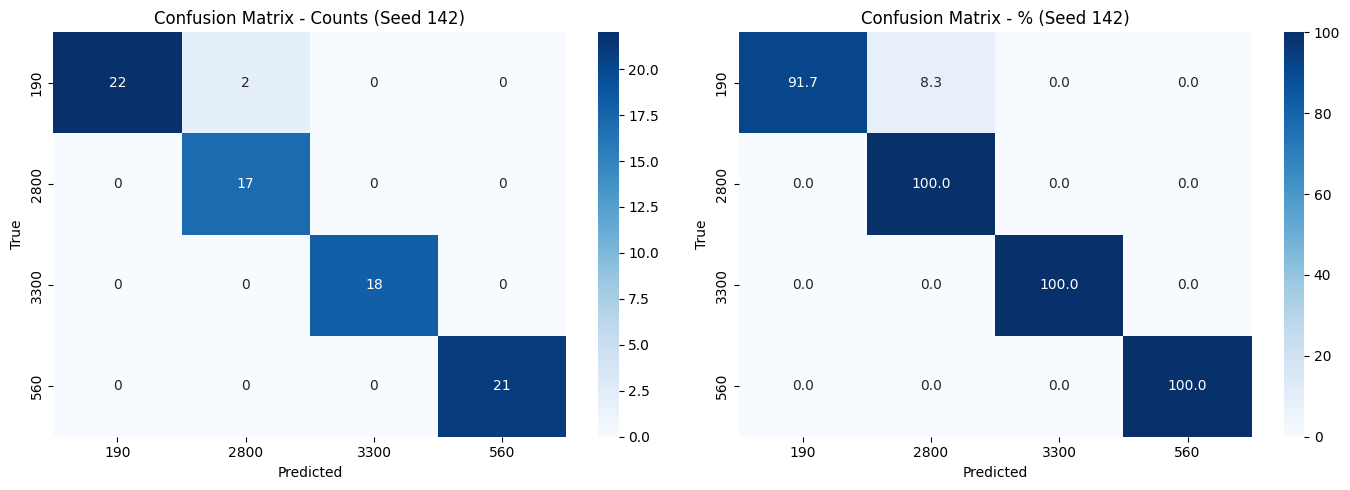

Seed 242 Epoch 1: Loss=0.7161 | Train Acc=0.7448 | Val Acc=0.3375
Seed 242 Epoch 2: Loss=0.0853 | Train Acc=0.9916 | Val Acc=0.3875
Seed 242 Epoch 3: Loss=0.0264 | Train Acc=0.9958 | Val Acc=0.3875
Seed 242 Epoch 4: Loss=0.0230 | Train Acc=1.0000 | Val Acc=0.5750
Seed 242 Epoch 5: Loss=0.0051 | Train Acc=1.0000 | Val Acc=0.7250
Seed 242 Epoch 6: Loss=0.0047 | Train Acc=1.0000 | Val Acc=0.8625
Seed 242 Epoch 7: Loss=0.0030 | Train Acc=1.0000 | Val Acc=0.9500
Seed 242 Epoch 8: Loss=0.0047 | Train Acc=1.0000 | Val Acc=0.9625
Seed 242 Epoch 9: Loss=0.0052 | Train Acc=1.0000 | Val Acc=0.9625
Seed 242 Epoch 10: Loss=0.0030 | Train Acc=1.0000 | Val Acc=0.9875
Seed 242 Epoch 11: Loss=0.0095 | Train Acc=1.0000 | Val Acc=0.9875
Seed 242 Epoch 12: Loss=0.0026 | Train Acc=1.0000 | Val Acc=0.9875
Seed 242 Epoch 13: Loss=0.0028 | Train Acc=1.0000 | Val Acc=1.0000
Seed 242 Epoch 14: Loss=0.0039 | Train Acc=1.0000 | Val Acc=0.9875
Seed 242 Epoch 15: Loss=0.0036 | Train Acc=1.0000 | Val Acc=1.0000
Seed

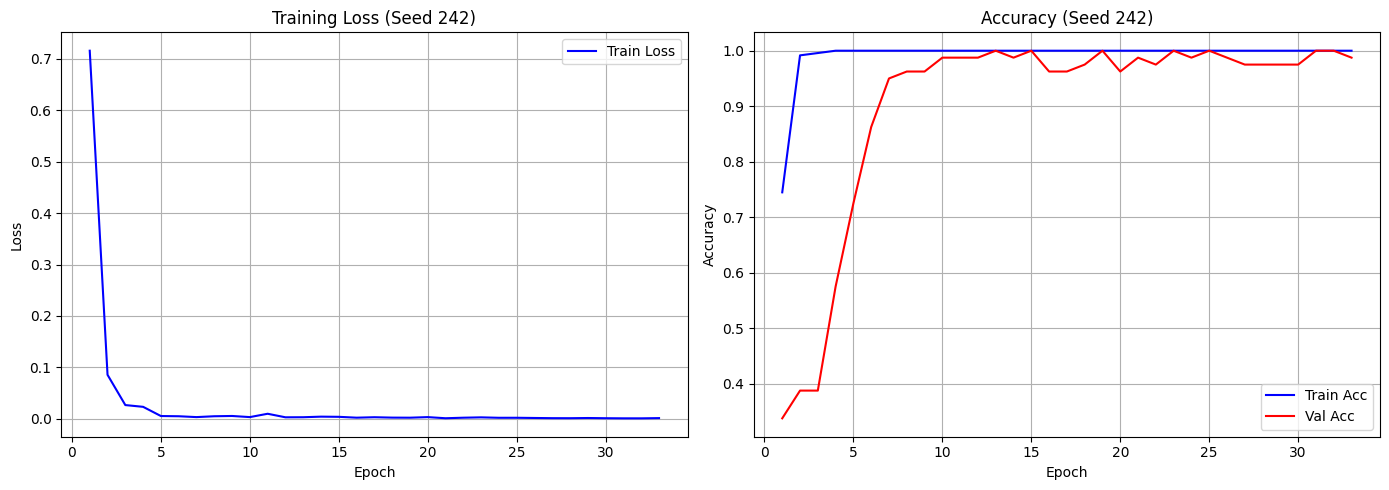

Loading best model from best_model_seed_242.pt for testing
Seed 242: Test Acc = 0.9750



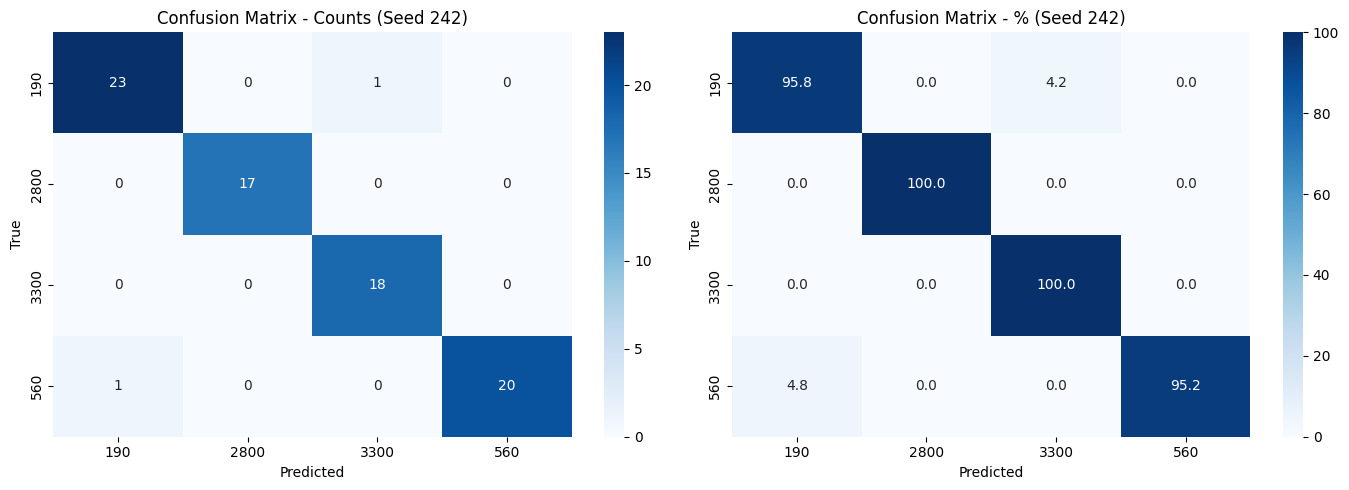

In [7]:
dataset_full = CustomImageDataset("CRP_dataset/crp_iphone/full", transform=transform)
dataset_black = CustomImageDataset("CRP_dataset/crp_iphone/black", transform=transform)
dataset_white = CustomImageDataset("CRP_dataset/crp_iphone/white", transform=transform)
labels = [dataset_full.preprocessed_data[path]['label'] for path in dataset_full.samples]

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_once(seed, dataset_full, dataset_black, dataset_white, labels):
    seed_everything(seed)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=seed)
    for train_idx, test_val_idx in sss.split(np.zeros(len(labels)), labels):
        temp_labels = [labels[i] for i in test_val_idx]
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        for val_idx_rel, test_idx_rel in sss_val.split(np.zeros(len(temp_labels)), temp_labels):
            val_idx = [test_val_idx[i] for i in val_idx_rel]
            test_idx = [test_val_idx[i] for i in test_idx_rel]

    train_full = Subset(dataset_full, train_idx)
    val_full = Subset(dataset_full, val_idx)
    test_full = Subset(dataset_full, test_idx)

    train_black = Subset(dataset_black, train_idx)
    val_black = Subset(dataset_black, val_idx)
    test_black = Subset(dataset_black, test_idx)

    train_white = Subset(dataset_white, train_idx)
    val_white = Subset(dataset_white, val_idx)
    test_white = Subset(dataset_white, test_idx)

    train_loader = DataLoader(list(zip(train_full, train_black, train_white)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(list(zip(val_full, val_black, val_white)), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(list(zip(test_full, test_black, test_white)), batch_size=batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = BwCombinedInteractModel50(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)


    best_acc = 0
    counter = 0
    best_model_path = f"best_model_seed_{seed}.pt"
    train_losses, train_accs, val_accs = [], [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss   = 0
        train_correct = 0
        train_total   = 0

        for batch in train_loader:
            (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
            optimizer.zero_grad()
            outputs = model(full_img.to(device), black_img.to(device), white_img.to(device))
            loss = criterion(outputs, label.to(device))
            loss.backward()
            optimizer.step()
            epoch_loss    += loss.item()
            _, predicted   = torch.max(outputs.data, 1)
            train_total   += label.size(0)
            train_correct += (predicted == label.to(device)).sum().item()
        scheduler.step()

        avg_loss  = epoch_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_loss)
        train_accs.append(train_acc)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in val_loader:
                (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
                outputs = model(full_img.to(device), black_img.to(device), white_img.to(device))
                _, predicted = torch.max(outputs.data, 1)
                total += label.size(0)
                correct += (predicted == label.to(device)).sum().item()

        val_acc = correct / total
        val_accs.append(val_acc)
        print(f"Seed {seed} Epoch {epoch+1}: Loss={avg_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1} with best val acc {best_acc:.4f}")
            break

    plot_curves(train_losses, train_accs, val_accs, seed)

    print(f"Loading best model from {best_model_path} for testing")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    all_preds  = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
            outputs = model(full_img.to(device), black_img.to(device), white_img.to(device))
            _, predicted = torch.max(outputs.data, 1)
            total += label.size(0)
            correct += (predicted == label.to(device)).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(label.numpy())

    test_acc = correct / total
    print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")
    plot_confusion_matrix(all_labels, all_preds, seed)

for repeat in range(repeats):
    seed = 42 + repeat * 100
    train_once(seed, dataset_full, dataset_black, dataset_white, labels)


Testing on different augmentations/filters (simulating images from diff devices)

In [8]:
import os
import random
from PIL import Image, ImageEnhance, ImageFilter
import numpy as np
from torchvision import transforms

def simulate_xiaomi(img):
    # Xiaomi: warm color temperature, slightly oversharped, moderate noise

    # Warm color temperature (boost reds/yellows)
    img = img.convert('RGB')
    r, g, b = img.split()
    r = ImageEnhance.Brightness(r).enhance(1.1)
    b = ImageEnhance.Brightness(b).enhance(0.85)
    img = Image.merge('RGB', (r, g, b))

    # Sharpness
    img = ImageEnhance.Sharpness(img).enhance(1.8)

    # Exposure (slightly brighter)
    img = ImageEnhance.Brightness(img).enhance(1.05)

    # Noise
    img_array = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 8, img_array.shape)
    img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)

    return Image.fromarray(img_array)

def simulate_vivo(img):
    # Vivo: cool color temperature, softer/beautified, low noise

    img = img.convert('RGB')
    r, g, b = img.split()
    r = ImageEnhance.Brightness(r).enhance(0.9)
    b = ImageEnhance.Brightness(b).enhance(1.15)
    img = Image.merge('RGB', (r, g, b))

    # Softer (vivo has beauty mode style processing)
    img = ImageEnhance.Sharpness(img).enhance(0.6)

    # Slight contrast boost
    img = ImageEnhance.Contrast(img).enhance(1.1)

    # Exposure (slightly darker/natural)
    img = ImageEnhance.Brightness(img).enhance(0.95)

    # Very low noise
    img_array = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 3, img_array.shape)
    img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)

    return Image.fromarray(img_array)

def augment_dataset(input_root, output_root, device_name, simulate_fn):
    """
    input_root:  CRP_dataset/crp_iphone/
    output_root: CRP_dataset/crp_xiaomi/  ya  CRP_dataset/crp_vivo/
    """
    backgrounds = ['black', 'full', 'white']
    classes = ['190', '560', '2800', '3300']

    for bg in backgrounds:
        for cls in classes:
            in_path  = os.path.join(input_root, bg, cls)
            out_path = os.path.join(output_root, bg, cls)
            os.makedirs(out_path, exist_ok=True)

            for fname in os.listdir(in_path):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img = Image.open(os.path.join(in_path, fname))
                aug = simulate_fn(img)
                aug.save(os.path.join(out_path, fname))

            print(f"Done: {bg}/{cls}")

# Run karo
augment_dataset(
    input_root  = "CRP_dataset/crp_iphone",
    output_root = "CRP_dataset/crp_xiaomi",
    device_name = "xiaomi",
    simulate_fn = simulate_xiaomi
)

augment_dataset(
    input_root  = "CRP_dataset/crp_iphone",
    output_root = "CRP_dataset/crp_vivo",
    device_name = "vivo",
    simulate_fn = simulate_vivo
)

Done: black/190
Done: black/560
Done: black/2800
Done: black/3300
Done: full/190
Done: full/560
Done: full/2800
Done: full/3300
Done: white/190
Done: white/560
Done: white/2800
Done: white/3300
Done: black/190
Done: black/560
Done: black/2800
Done: black/3300
Done: full/190
Done: full/560
Done: full/2800
Done: full/3300
Done: white/190
Done: white/560
Done: white/2800
Done: white/3300


Starting load Dataset: CRP_dataset/crp_vivo/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_vivo/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_vivo/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Loading best model from best_model_seed_242.pt for testing


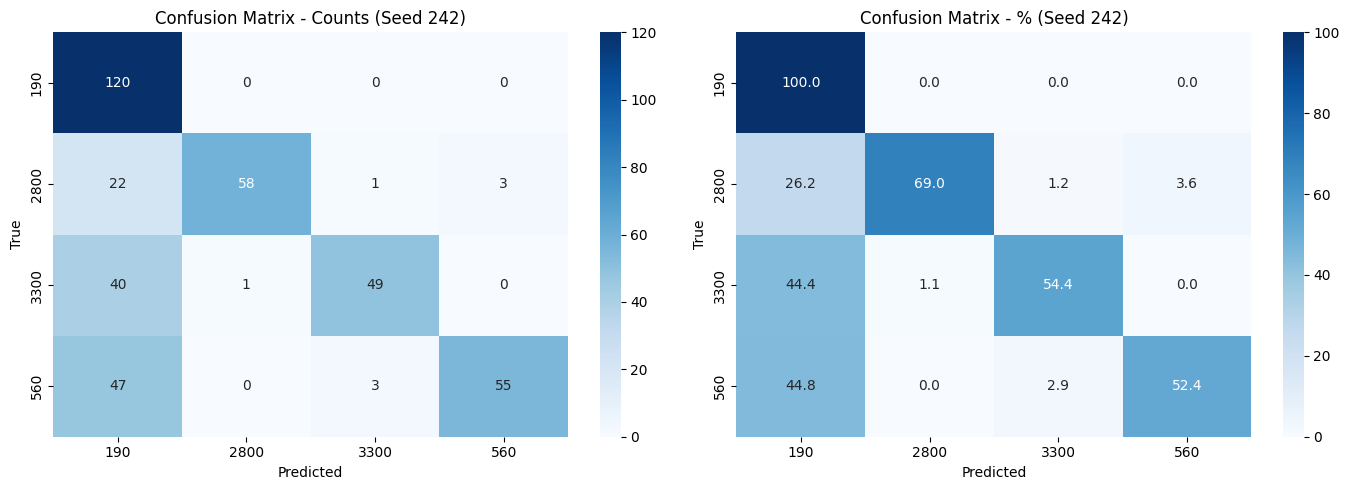

Seed 242: Test Acc = 0.7068



In [13]:
dataset_full = CustomImageDataset("CRP_dataset/crp_vivo/full", transform=transform)
dataset_black = CustomImageDataset("CRP_dataset/crp_vivo/black", transform=transform)
dataset_white = CustomImageDataset("CRP_dataset/crp_vivo/white", transform=transform)

seed = 242
test_loader = DataLoader(list(zip(dataset_full, dataset_black, dataset_white)), batch_size=batch_size, shuffle=False)

print(f"Loading best model from best_model_seed_{seed}.pt for testing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BwCombinedInteractModel50(num_classes=4).to(device)
model.load_state_dict(torch.load('best_model_seed_242.pt'))
model.eval()

all_preds  = []
all_labels = []
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
        outputs = model(full_img.to(device), black_img.to(device), white_img.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += label.size(0)
        correct += (predicted == label.to(device)).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.numpy())

plot_confusion_matrix(all_labels, all_preds, seed)
test_acc = correct / total
print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")

Starting load Dataset: CRP_dataset/crp_xiaomi/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Loading best model from best_model_seed_242.pt for testing


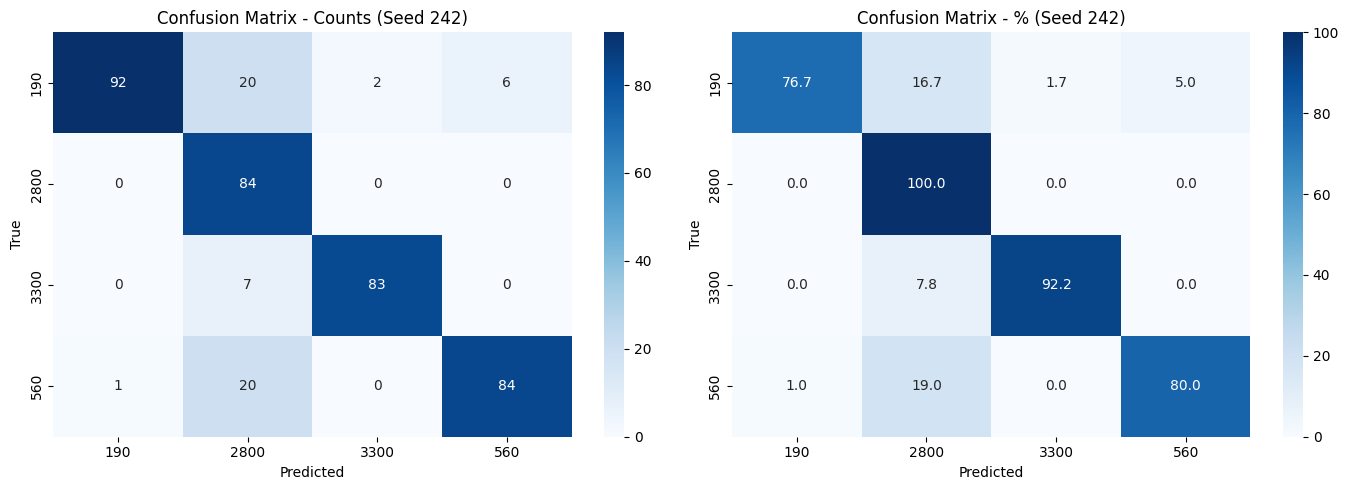

Seed 242: Test Acc = 0.8596



In [14]:
dataset_full = CustomImageDataset("CRP_dataset/crp_xiaomi/full", transform=transform)
dataset_black = CustomImageDataset("CRP_dataset/crp_xiaomi/black", transform=transform)
dataset_white = CustomImageDataset("CRP_dataset/crp_xiaomi/white", transform=transform)

test_loader = DataLoader(list(zip(dataset_full, dataset_black, dataset_white)), batch_size=batch_size, shuffle=False)

print(f"Loading best model from best_model_seed_{seed}.pt for testing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BwCombinedInteractModel50(num_classes=4).to(device)
model.load_state_dict(torch.load('best_model_seed_242.pt'))
model.eval()

all_preds  = []
all_labels = []
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
        outputs = model(full_img.to(device), black_img.to(device), white_img.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += label.size(0)
        correct += (predicted == label.to(device)).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.numpy())

plot_confusion_matrix(all_labels, all_preds, seed)
test_acc = correct / total
print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")

In [ ]:
import shutil
from google.colab import files
shutil.make_archive("CRP_dataset", "zip", "CRP_dataset")
files.download("CRP_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

With maml
model.py se layer freezing wali cheez hata dena for this
layer freezing hatane se parameters itne saare hain k cuda out of memory issue aaraha hai. let's move to clip now

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np
import random
import os
from dataload import CustomImageDataset
from models import BwCombinedInteractModel50

# ─── Config ───────────────────────────────────────────
num_classes  = 4
n_shot       = 5      # support set per class
n_query      = 5      # query set per class
n_episodes   = 100    # meta-training episodes
inner_lr     = 0.01   # inner loop learning rate
inner_steps  = 5      # inner loop gradient steps
outer_lr     = 1e-4   # outer loop (meta) learning rate
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ─── Episode Sampler ──────────────────────────────────
class EpisodeSampler:
    """
    Har episode mein teeno domains (full/black/white) se
    synchronized support aur query sets banata hai
    """
    def __init__(self, dataset_full, dataset_black, dataset_white, n_classes, n_shot, n_query):
        self.datasets = {
            'full':  dataset_full,
            'black': dataset_black,
            'white': dataset_white
        }
        self.n_classes = n_classes
        self.n_shot    = n_shot
        self.n_query   = n_query

        # Class ke hisaab se indices group karo
        self.class_indices = {i: [] for i in range(n_classes)}
        for idx, path in enumerate(dataset_full.samples):
            label = dataset_full.preprocessed_data[path]['label']
            self.class_indices[label].append(idx)

    def sample_episode(self):
        support, query = {'full': [], 'black': [], 'white': []}, \
                         {'full': [], 'black': [], 'white': []}
        support_labels, query_labels = [], []

        for cls in range(self.n_classes):
            indices = random.sample(
                self.class_indices[cls],
                self.n_shot + self.n_query
            )
            sup_idx, qry_idx = indices[:self.n_shot], indices[self.n_shot:]

            for domain in ['full', 'black', 'white']:
                ds = self.datasets[domain]
                support[domain].extend([ds[i][0] for i in sup_idx])
                query[domain].extend([ds[i][0]   for i in qry_idx])

            support_labels.extend([cls] * self.n_shot)
            query_labels.extend([cls]   * self.n_query)

        # Stack into tensors
        for domain in ['full', 'black', 'white']:
            support[domain] = torch.stack(support[domain]).to(device)
            query[domain]   = torch.stack(query[domain]).to(device)

        support_labels = torch.tensor(support_labels).to(device)
        query_labels   = torch.tensor(query_labels).to(device)

        return support, query, support_labels, query_labels


# ─── Inner Loop ───────────────────────────────────────
def inner_loop(model, support, support_labels, inner_lr, inner_steps, criterion):
    """
    Support set pe fast adapt karo — forward_with_weights use hoga
    """
    # Current weights copy karo
    fast_weights = list(model.parameters())

    for step in range(inner_steps):
        # Forward pass with current fast weights
        logits = model.forward_with_weights(
            support['full'],
            support['black'],
            support['white'],
            fast_weights
        )
        loss = criterion(logits, support_labels)

        # Gradients nikalo fast weights ke against
        grads = torch.autograd.grad(loss, fast_weights, create_graph=True)

        # Fast weights update karo (SGD style)
        fast_weights = [w - inner_lr * g for w, g in zip(fast_weights, grads)]

    return fast_weights


# ─── Meta Training ────────────────────────────────────
def meta_train(source_sampler, model, meta_optimizer, criterion,
               n_episodes, inner_lr, inner_steps):

    model.train()
    for episode in range(n_episodes):
        support, query, sup_labels, qry_labels = source_sampler.sample_episode()

        # Inner loop — support pe adapt
        fast_weights = inner_loop(model, support, sup_labels,
                                  inner_lr, inner_steps, criterion)

        # Outer loop — query pe loss (adapted weights se)
        query_logits = model.forward_with_weights(
            query['full'],
            query['black'],
            query['white'],
            fast_weights
        )
        meta_loss = criterion(query_logits, qry_labels)

        meta_optimizer.zero_grad()
        meta_loss.backward()
        meta_optimizer.step()

        if (episode + 1) % 10 == 0:
            _, predicted = torch.max(query_logits, 1)
            acc = (predicted == qry_labels).float().mean().item()
            print(f"Episode {episode+1}/{n_episodes} | "
                  f"Meta Loss: {meta_loss.item():.4f} | "
                  f"Query Acc: {acc:.4f}")


# ─── Meta Testing ─────────────────────────────────────
def meta_test(target_sampler, model, criterion,
              inner_lr, inner_steps, n_test_episodes=50):
    """
    Target domain (Xiaomi/Vivo) pe few-shot test
    """
    model.eval()
    accs = []

    for episode in range(n_test_episodes):
        support, query, sup_labels, qry_labels = target_sampler.sample_episode()

        # Inner loop — target domain pe adapt
        fast_weights = inner_loop(model, support, sup_labels,
                                  inner_lr, inner_steps, criterion)

        # Query pe evaluate
        with torch.no_grad():
            query_logits = model.forward_with_weights(
                query['full'],
                query['black'],
                query['white'],
                fast_weights
            )
        _, predicted = torch.max(query_logits, 1)
        acc = (predicted == qry_labels).float().mean().item()
        accs.append(acc)

    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    print(f"Meta-Test Acc: {mean_acc:.4f} ± {std_acc:.4f}")
    return mean_acc


# ─── Main ─────────────────────────────────────────────
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(42)

# iPhone — source domain (meta-train)
iphone_full  = CustomImageDataset("CRP_dataset/crp_iphone/full",  transform=transform)
iphone_black = CustomImageDataset("CRP_dataset/crp_iphone/black", transform=transform)
iphone_white = CustomImageDataset("CRP_dataset/crp_iphone/white", transform=transform)

# Xiaomi — target domain (meta-test)
xiaomi_full  = CustomImageDataset("CRP_dataset/crp_xiaomi/full",  transform=transform)
xiaomi_black = CustomImageDataset("CRP_dataset/crp_xiaomi/black", transform=transform)
xiaomi_white = CustomImageDataset("CRP_dataset/crp_xiaomi/white", transform=transform)

# Vivo — target domain (meta-test)
vivo_full  = CustomImageDataset("CRP_dataset/crp_vivo/full",  transform=transform)
vivo_black = CustomImageDataset("CRP_dataset/crp_vivo/black", transform=transform)
vivo_white = CustomImageDataset("CRP_dataset/crp_vivo/white", transform=transform)

# Samplers
iphone_sampler = EpisodeSampler(iphone_full, iphone_black, iphone_white,
                                num_classes, n_shot, n_query)
xiaomi_sampler = EpisodeSampler(xiaomi_full, xiaomi_black, xiaomi_white,
                                num_classes, n_shot, n_query)
vivo_sampler   = EpisodeSampler(vivo_full,   vivo_black,   vivo_white,
                                num_classes, n_shot, n_query)

# Model — pehle se trained iPhone weights load karo
model = BwCombinedInteractModel50(num_classes=num_classes).to(device)

criterion      = nn.CrossEntropyLoss()
meta_optimizer = optim.Adam(model.parameters(), lr=outer_lr)

# Meta-train on iPhone
print("=== Meta Training (iPhone) ===")
meta_train(iphone_sampler, model, meta_optimizer, criterion,
           n_episodes, inner_lr, inner_steps)

# Meta-test on Xiaomi aur Vivo
print("\n=== Meta Test: Xiaomi ===")
meta_test(xiaomi_sampler, model, criterion, inner_lr, inner_steps)

print("\n=== Meta Test: Vivo ===")
meta_test(vivo_sampler, model, criterion, inner_lr, inner_steps)

Starting load Dataset: CRP_dataset/crp_iphone/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_iphone/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_iphone/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images


OutOfMemoryError: CUDA out of memory. Tried to allocate 62.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 23.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.24 GiB is allocated by PyTorch, and 163.91 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)